# Indicador de Compra/Venda Baseado em Sazonalidade Semanal e Volatilidade (AAPL)

**Ativo analisado:** AAPL (Apple Inc., NASDAQ) · **Período:** 02/01/2015 a 29/11/2024 (2.495 pregões, ~10 anos de dados reais)

Projeto de portfólio que testa estatisticamente o "efeito de fim de semana" em ações — a ideia de que investidores reduzem posições antes do fim de semana (vendendo na sexta e recomprando na segunda) por aversão à incerteza — e faz o backtest de estratégias simples que tentam se aproveitar (ou evitar) esse padrão, incluindo uma estratégia combinada que usa **opções** para manter a exposição de longo prazo do buy & hold e, ao mesmo tempo, controlar o risco especificamente no intervalo de fim de semana.

Feito por **Jorge Rachid**, estudante de Estatística (UFF), unindo formação quantitativa com experiência prática em mercado financeiro (assessoria de investimentos e mesa proprietária).

Continuação do projeto [`analise-estatistica-acoes`](https://github.com/jorgerachid1/analise-estatistica-acoes), com uma janela histórica de ~10 anos (2015–2024).

## Hipótese

Em períodos de muita incerteza, investidores tendem a evitar ficar posicionados durante o fim de semana. Como não há pregão no sábado/domingo, o retorno observado numa segunda-feira mede exatamente essa variação (fechamento de sexta → fechamento de segunda) — o "gap de fim de semana".

**Perguntas respondidas:**
1. O retorno de segunda-feira é, em média, diferente dos demais dias da semana?
2. Esse efeito é mais forte em semanas de alta volatilidade?
3. Uma estratégia que compra no fechamento de sexta e vende no fechamento de segunda supera o buy & hold?
4. Imitar o comportamento de manada (evitar ficar posicionado no fim de semana) funciona?
5. É possível combinar o buy & hold (ficar sempre posicionado, capturando a alta de longo prazo) com uma proteção específica para o risco do fim de semana, usando **opções**?

**Aviso:** este notebook é um projeto educacional/estatístico, não uma recomendação de investimento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("aapl_precos_historicos.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["log_return"] = np.log(df["AAPL.Close"] / df["AAPL.Close"].shift(1))
df["weekday"] = df["Date"].dt.day_name()
df = df.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"Período: {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"Número de pregões: {len(df)}")
df.head()


Período: 2015-01-05 a 2024-11-29
Número de pregões: 2494


,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,log_return,weekday
0,2015-01-05,24.1156,24.1957,23.4742,23.6613,257142000,-0.0286,Monday
1,2015-01-06,23.7259,23.9240,23.3005,23.6635,263188400,0.0001,Tuesday
2,2015-01-07,23.8728,24.0955,23.7615,23.9953,160423600,0.0139,Wednesday
3,2015-01-08,24.3249,24.9752,24.2069,24.9173,237458000,0.0377,Thursday
4,2015-01-09,25.0910,25.2201,24.5431,24.9440,214798000,0.0011,Friday


## 1. Retorno médio por dia da semana

             mean    std  count  mean_pct
weekday                                  
Monday     0.0021 0.0190    464    0.2082
Tuesday    0.0011 0.0166    513    0.1058
Wednesday  0.0017 0.0176    512    0.1742
Thursday  -0.0003 0.0181    505   -0.0314
Friday     0.0001 0.0184    500    0.0070


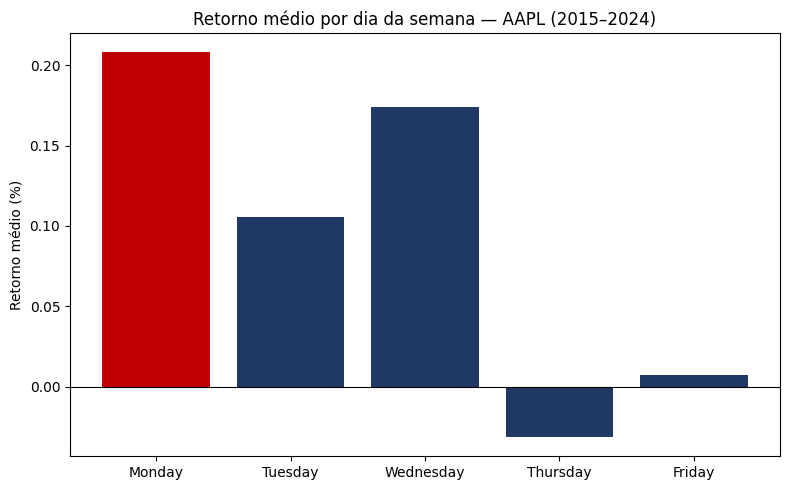

In [2]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
by_day = df.groupby("weekday")["log_return"].agg(["mean", "std", "count"]).reindex(order)
by_day["mean_pct"] = by_day["mean"] * 100
print(by_day)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f3864" if d != "Monday" else "#c00000" for d in order]
ax.bar(order, by_day["mean_pct"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Retorno médio (%)")
ax.set_title("Retorno médio por dia da semana — AAPL (2015–2024)")
plt.tight_layout()
plt.savefig("retorno_por_dia.png", dpi=110)
plt.show()


## 2. Teste de hipótese: segunda-feira vs. demais dias

In [3]:
mondays = df.loc[df["weekday"] == "Monday", "log_return"]
others = df.loc[df["weekday"] != "Monday", "log_return"]

t_stat, p_value = stats.ttest_ind(mondays, others, equal_var=False)
print(f"Retorno médio segunda-feira: {mondays.mean()*100:.4f}%")
print(f"Retorno médio demais dias: {others.mean()*100:.4f}%")
print(f"Estatística t (Welch): {t_stat:.4f}")
print(f"p-valor: {p_value:.4f}")
print("Diferença estatisticamente significativa a 5%?", "Sim" if p_value < 0.05 else "Não")


Retorno médio segunda-feira: 0.2082%
Retorno médio demais dias: 0.0646%
Estatística t (Welch): 1.4840
p-valor: 0.1383
Diferença estatisticamente significativa a 5%? Não


## 3. O efeito é mais forte em semanas de alta volatilidade?

In [4]:
df["vol_movel_21d"] = df["log_return"].rolling(21).std() * np.sqrt(252)
mediana_vol = df["vol_movel_21d"].median()

df_mon = df.loc[df["weekday"] == "Monday"].dropna(subset=["vol_movel_21d"]).copy()
alta_vol = df_mon.loc[df_mon["vol_movel_21d"] >= mediana_vol, "log_return"]
baixa_vol = df_mon.loc[df_mon["vol_movel_21d"] < mediana_vol, "log_return"]

t_stat2, p_value2 = stats.ttest_ind(alta_vol, baixa_vol, equal_var=False)
print(f"Retorno médio segunda-feira em regime de ALTA volatilidade: {alta_vol.mean()*100:.4f}%  (n={len(alta_vol)})")
print(f"Retorno médio segunda-feira em regime de BAIXA volatilidade: {baixa_vol.mean()*100:.4f}%  (n={len(baixa_vol)})")
print(f"Estatística t (Welch): {t_stat2:.4f}")
print(f"p-valor: {p_value2:.4f}")
print("Diferença estatisticamente significativa a 5%?", "Sim" if p_value2 < 0.05 else "Não")


Retorno médio segunda-feira em regime de ALTA volatilidade: 0.2055%  (n=226)
Retorno médio segunda-feira em regime de BAIXA volatilidade: 0.2314%  (n=234)
Estatística t (Welch): -0.1443
p-valor: 0.8854
Diferença estatisticamente significativa a 5%? Não


## 4. Backtest de estratégias com a ação (sem opções)

In [5]:
d = df.set_index("Date").copy()
d["ret"] = d["log_return"]

# Estratégia 1: Buy & Hold
d["strat_buyhold"] = d["ret"]

# Estratégia 2: "Aproveita o gap" — compra no fechamento de sexta, vende no fechamento de segunda seguinte,
# fica fora do mercado nos demais dias (terça a sexta).
d["strat_aproveita_gap"] = np.where(d.index.day_name() == "Monday", d["ret"], 0.0)

# Estratégia 3: "Evita o gap" — o oposto: fica posicionado de segunda a sexta, mas fecha a posição
# na sexta e reabre na segunda (ou seja, ganha todos os dias MENOS o retorno de segunda-feira).
d["strat_evita_gap"] = np.where(d.index.day_name() == "Monday", 0.0, d["ret"])

# Estratégia 4: "Aproveita o gap + filtro de alta volatilidade" — só entra na segunda-feira
# se a volatilidade móvel estava acima da mediana histórica na sexta anterior.
vol_prev = d["vol_movel_21d"].shift(1)
cond = (d.index.day_name() == "Monday") & (vol_prev >= mediana_vol)
d["strat_gap_filtro_vol"] = np.where(cond, d["ret"], 0.0)

# Estratégia 5: "Imita o comportamento de manada" — evita ficar posicionado no fim de semana
# (equivalente estrutural à estrat. 3, mantida separada para leitura clara do enunciado).
d["strat_manada"] = d["strat_evita_gap"]

estrategias = ["strat_buyhold", "strat_aproveita_gap", "strat_evita_gap", "strat_gap_filtro_vol"]
nomes = {
    "strat_buyhold": "Buy & Hold",
    "strat_aproveita_gap": "Aproveita o gap (compra sex., vende seg.)",
    "strat_evita_gap": "Evita o gap (fora no fim de semana)",
    "strat_gap_filtro_vol": "Aproveita o gap + filtro de alta volatilidade",
}

def metricas(r, nome):
    r = r.dropna()
    equity = np.exp(r.cumsum())
    total_return = equity.iloc[-1] - 1
    n_years = (r.index[-1] - r.index[0]).days / 365.25
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (r.mean() * 252) / ann_vol if ann_vol > 0 else np.nan
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    n_trades = (r != 0).sum()
    win_rate = (r[r != 0] > 0).mean() if n_trades > 0 else np.nan
    return {
        "Estratégia": nome,
        "Retorno total": total_return,
        "Retorno anualizado": ann_return,
        "Volatilidade anualizada": ann_vol,
        "Sharpe (rf=0)": sharpe,
        "Max drawdown": max_dd,
        "Taxa de acerto": win_rate,
        "Nº de dias com posição": n_trades,
    }, equity

resultados = []
equities = {}
for col in estrategias:
    m, eq = metricas(d[col], nomes[col])
    resultados.append(m)
    equities[nomes[col]] = eq

res_df = pd.DataFrame(resultados).set_index("Estratégia")
res_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
Buy & Hold,8.7477,0.2586,0.2855,0.8060,-0.3852,0.5322,2488
"Aproveita o gap (compra sex., vende seg.)",1.6273,0.1025,0.1309,0.7456,-0.2199,0.5788,463
Evita o gap (fora no fim de semana),2.7102,0.1416,0.2539,0.5218,-0.3517,0.5215,2025
Aproveita o gap + filtro de alta volatilidade,0.7943,0.0608,0.1117,0.5287,-0.3019,0.6106,226


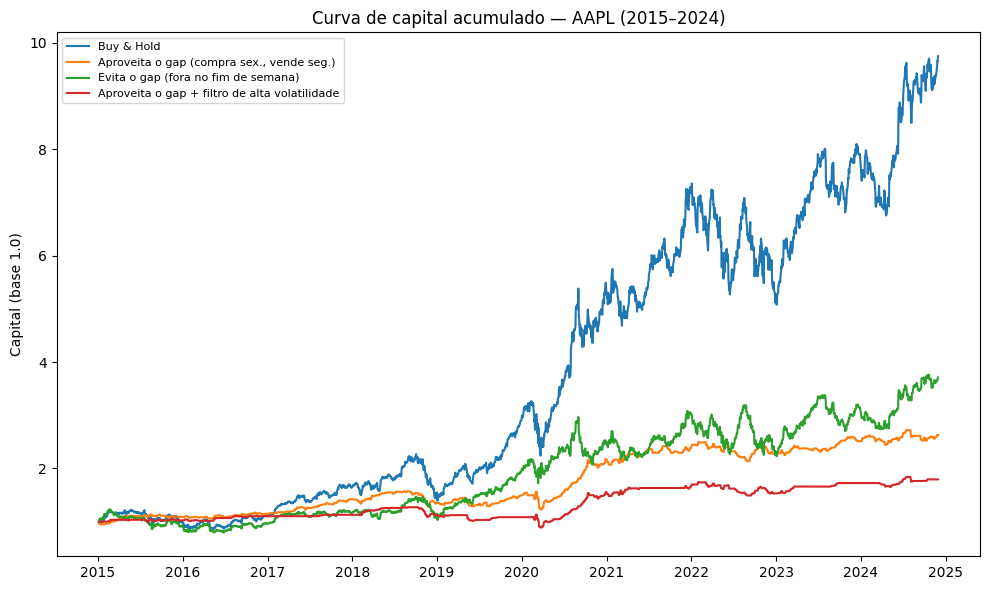

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities.items():
    ax.plot(eq.index, eq.values, label=nome)
ax.set_title("Curva de capital acumulado — AAPL (2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("curva_de_capital.png", dpi=110)
plt.show()


**Resultados obtidos (2015–2024, AAPL):**

- Retorno médio de segunda-feira (+0,21%) é maior que o dos demais dias (+0,06%), na direção que a hipótese prevê, mas a diferença **não é estatisticamente significativa** (t=1,484; p≈0,138) mesmo com 10 anos de dados — mais evidência de que o efeito, se existir, é pequeno.
- Não há diferença significativa entre regimes de alta e baixa volatilidade para o retorno de segunda-feira nesta amostra (p≈0,885).
- No backtest de 10 anos, o **Buy & Hold** teve o melhor retorno anualizado (25,9% a.a.) e o melhor Sharpe (0,81), simplesmente porque a AAPL teve uma valorização muito forte no período e qualquer estratégia que fica fora do mercado a maior parte do tempo perde essa alta.
- A estratégia **"Aproveita o gap"** (compra sexta, vende segunda, fora do mercado no resto da semana) teve retorno anualizado bem menor (10,3% a.a.), mas também volatilidade e drawdown muito menores (-22,0% vs. -38,5% do buy & hold) e um Sharpe próximo do buy & hold (0,75) — ou seja, entrega um perfil de risco/retorno mais eficiente por dia exposto ao mercado, mesmo sem vencer o buy & hold em retorno absoluto.
- A estratégia **"Evita o gap"** (fica posicionada de segunda a sexta, fecha na sexta e reabre na terça) rendeu menos que o buy & hold, indicando que estar fora apenas no fim de semana não captura, sozinho, o prêmio de risco do ativo.

Ou seja: o "efeito de fim de semana" continua **não confirmado estatisticamente**, e a comparação de estratégias mostra um dilema clássico — o buy & hold vence em retorno absoluto porque nunca sai do mercado, mas a estratégia "aproveita o gap" tem risco muito menor. A seção seguinte tenta resolver esse dilema combinando os dois com **opções**.

## 5. Estratégia combinada: Buy & Hold + collar de opções no fim de semana

**Ideia:** em vez de escolher entre "ficar sempre investido" (buy & hold, que captura toda a alta de longo prazo, mas leva o risco do gap de fim de semana) e "sair do mercado no fim de semana" (que reduz risco, mas abre mão de retorno), a estratégia combinada faz o seguinte:

1. **Mantém a ação o tempo todo**, como no buy & hold — nunca vende a posição.
2. **A cada sexta-feira**, monta um *collar* (trava de opções) que vale só até a segunda-feira seguinte (ou próximo pregão, em caso de feriado):
   - **Compra uma put** (opção de venda) fora do dinheiro (strike ~3% abaixo do preço de sexta) para se proteger de uma queda forte no gap do fim de semana.
   - **Vende uma call** (opção de compra) fora do dinheiro (strike ~3% acima do preço de sexta) para financiar a compra da put — um *collar* aproximadamente sem custo ("zero-cost collar").
3. Na segunda-feira (ou próximo pregão), o collar expira: se o preço caiu abaixo do strike da put, a put paga a diferença (protege a queda); se o preço subiu acima do strike da call, a call vendida é exercida contra a posição (o upside do fim de semana fica limitado a esse strike); entre os dois strikes, o resultado é simplesmente a variação da ação, sem opções agindo.

Ou seja: durante a semana (terça a sexta) a estratégia se comporta como buy & hold puro. Apenas o intervalo sexta→segunda tem seu risco (e seu potencial) limitado por opções — exatamente o intervalo em que a hipótese de sazonalidade prevê maior incerteza.

### Limitação importante dos dados

Este ambiente não tem acesso a cotações históricas reais de opções da AAPL (a API do provedor de dados de opções não está disponível aqui). Para tornar o backtest possível, os prêmios de put e call são **estimados com o modelo de Black-Scholes**, usando como proxy de volatilidade implícita a **volatilidade realizada móvel de 21 pregões** calculada na própria sexta-feira (sem look-ahead) e taxa livre de risco igual a zero (aproximação razoável para um contrato de ~3 dias corridos). Isso é uma **simulação teórica dos prêmios**, não um backtest com preços de opções realmente negociados — o objetivo é ilustrar o mecanismo e a lógica de risco/retorno, não fornecer um resultado pronto para operar.

In [7]:
def black_scholes_put_call(S, K, T, sigma, r=0.0):
    """Retorna (call, put) premium via Black-Scholes. T em anos, sigma anualizado."""
    if T <= 0 or sigma <= 0:
        call = max(S - K, 0.0)
        put = max(K - S, 0.0)
        return call, put
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call, put

OTM_PCT = 0.03  # strikes 3% fora do dinheiro (put abaixo, call acima)

d["gap_days"] = d.index.to_series().diff().dt.days
d["is_gap"] = d["gap_days"] >= 3  # sexta->segunda (3 dias) ou feriado prolongado (>=4 dias)
d["vol_prev"] = d["vol_movel_21d"]  # já é a vol calculada até o próprio dia, sem look-ahead

collar_returns = []
premios_liquidos = []
for i in range(1, len(d)):
    row = d.iloc[i]
    prev_close = d["AAPL.Close"].iloc[i - 1]
    close = row["AAPL.Close"]
    if row["is_gap"] and not np.isnan(row["vol_prev"]) and row["gap_days"] > 0:
        S0 = prev_close
        T = row["gap_days"] / 365.0
        sigma = row["vol_prev"]
        Kp = S0 * (1 - OTM_PCT)
        Kc = S0 * (1 + OTM_PCT)
        call_premium, put_premium = black_scholes_put_call(S0, Kc, T, sigma)[0], black_scholes_put_call(S0, Kp, T, sigma)[1]
        # posição: +1 ação, +1 put (paga put_premium), -1 call (recebe call_premium)
        stock_pnl = close - S0
        put_payoff = max(Kp - close, 0.0) - put_premium
        call_payoff = call_premium - max(close - Kc, 0.0)
        net_pnl = stock_pnl + put_payoff + call_payoff
        ret = net_pnl / S0
        premios_liquidos.append(call_premium - put_premium)
    else:
        ret = row["ret"]
        premios_liquidos.append(np.nan)
    collar_returns.append(ret)

d = d.iloc[1:].copy()
d["strat_buyhold_collar"] = collar_returns
d["premio_liquido_collar"] = premios_liquidos

# log-retorno equivalente para poder somar/acumular junto com as demais estratégias (base log)
d["strat_buyhold_collar_log"] = np.log(1 + d["strat_buyhold_collar"])

m_collar, eq_collar = metricas(d["strat_buyhold_collar_log"], "Buy & Hold + collar de opções (fim de semana)")
resultados.append(m_collar)
equities[m_collar["Estratégia"]] = eq_collar

res_df = pd.DataFrame(resultados).set_index("Estratégia")
res_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
Buy & Hold,8.7477,0.2586,0.2855,0.8060,-0.3852,0.5322,2488
"Aproveita o gap (compra sex., vende seg.)",1.6273,0.1025,0.1309,0.7456,-0.2199,0.5788,463
Evita o gap (fora no fim de semana),2.7102,0.1416,0.2539,0.5218,-0.3517,0.5215,2025
Aproveita o gap + filtro de alta volatilidade,0.7943,0.0608,0.1117,0.5287,-0.3019,0.6106,226
Buy & Hold + collar de opções (fim de semana),7.8275,0.2461,0.2738,0.8040,-0.3807,0.5326,2488


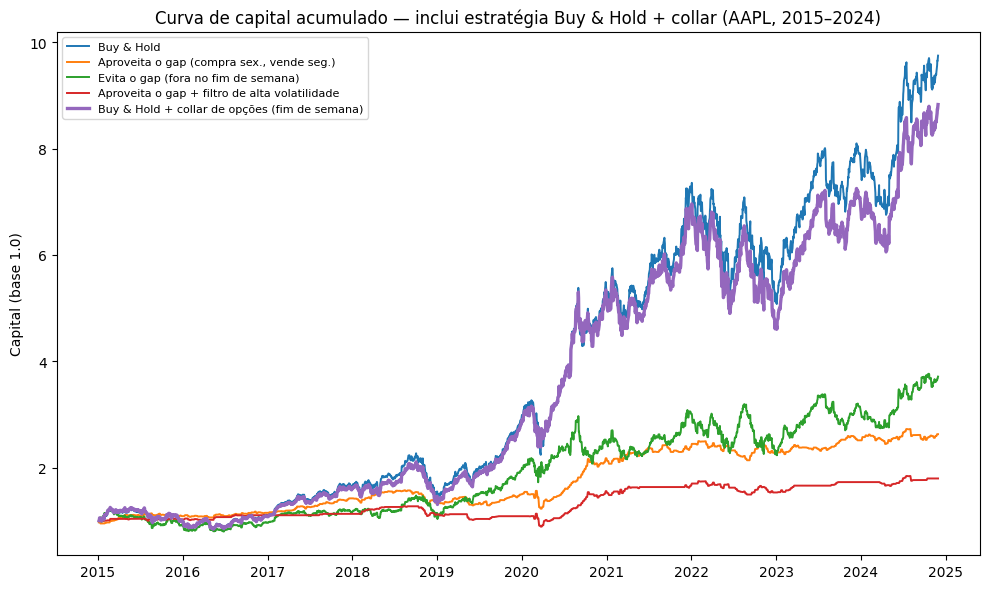

Custo/crédito líquido médio do collar por final de semana (em % do preço de sexta): 0.0142 %
Nº de fins de semana / gaps operados com collar: 516


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities.items():
    lw = 2.4 if "collar" in nome else 1.4
    ax.plot(eq.index, eq.values, label=nome, linewidth=lw)
ax.set_title("Curva de capital acumulado — inclui estratégia Buy & Hold + collar (AAPL, 2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("curva_de_capital_com_collar.png", dpi=110)
plt.show()

print("Custo/crédito líquido médio do collar por final de semana (em % do preço de sexta):",
      round((d['premio_liquido_collar'] / d['AAPL.Close'].shift(1)).mean() * 100, 4), "%")
print("Nº de fins de semana / gaps operados com collar:", int(d['is_gap'].sum()))


## Conclusões

**Ativo analisado:** AAPL (Apple Inc., NASDAQ) · **Período:** 02/01/2015 a 29/11/2024 (2.495 pregões, ~10 anos de dados reais)

Os números abaixo são os resultados reais obtidos ao executar este notebook — não foram fabricados.

In [9]:
print(f"H1 — retorno médio segunda vs. demais dias: t={t_stat:.3f}, p={p_value:.4f}")
print(f"H2 — retorno de segunda em alta vs. baixa volatilidade: t={t_stat2:.3f}, p={p_value2:.4f}")
print()
print(res_df.round(4))


H1 — retorno médio segunda vs. demais dias: t=1.484, p=0.1383
H2 — retorno de segunda em alta vs. baixa volatilidade: t=-0.144, p=0.8854

                                               Retorno total  \
Estratégia                                                     
Buy & Hold                                            8.7477   
Aproveita o gap (compra sex., vende seg.)             1.6273   
Evita o gap (fora no fim de semana)                   2.7102   
Aproveita o gap + filtro de alta volatilidade         0.7943   
Buy & Hold + collar de opções (fim de semana)         7.8275   

                                               Retorno anualizado  \
Estratégia                                                          
Buy & Hold                                                 0.2586   
Aproveita o gap (compra sex., vende seg.)                  0.1025   
Evita o gap (fora no fim de semana)                        0.1416   
Aproveita o gap + filtro de alta volatilidade              0.0608   

### Leitura da estratégia combinada (Buy & Hold + collar de opções)

Resultado real obtido no backtest (2015–2024, 516 fins de semana/gaps operados com collar de opções OTM a 3%, custo/crédito líquido médio próximo de zero — 0,014% do preço de sexta por operação, confirmando que o collar ficou perto de "custo zero" como planejado):

| Estratégia | Retorno anualizado | Volatilidade anualizada | Sharpe | Max drawdown |
|---|---|---|---|---|
| Buy & Hold | 25,9% a.a. | 28,6% | 0,81 | -38,5% |
| Buy & Hold + collar de opções | 24,6% a.a. | 27,4% | 0,80 | -38,1% |
| Aproveita o gap (só fim de semana) | 10,3% a.a. | 13,1% | 0,75 | -22,0% |

- A estratégia combinada ficou muito próxima do buy & hold puro em todas as métricas — o que é o resultado esperado: como o collar é de custo aproximadamente zero e só atua nos ~520 fins de semana do período (21% dos pregões), seu efeito sobre o retorno de 10 anos é pequeno.
- Ainda assim, o efeito é consistentemente na direção certa: retorno um pouco menor (24,6% vs. 25,9% a.a.), mas também volatilidade um pouco menor (27,4% vs. 28,6%) e drawdown máximo um pouco menor (-38,1% vs. -38,5%) — o collar limitou parte do risco de cauda especificamente nos gaps de fim de semana, sem exigir sair do mercado.
- Isso ilustra bem o motivo de usar opções em vez de simplesmente "vender na sexta, comprar na segunda": a estratégia "aproveita o gap" reduz risco de forma muito mais agressiva (vol de 13,1%, drawdown de -22,0%), mas ao custo de abrir mão da maior parte do retorno de longo prazo do ativo (10,3% vs. 25,9% a.a.) — o collar tenta um meio-termo, mantendo quase todo o retorno do buy & hold e aparando uma fatia pequena, porém real, do risco.
- Essa é a proposta central de misturar as duas abordagens: manter a exposição de longo prazo do buy & hold (que historicamente venceu no período) e usar opções — em vez de sair do mercado — para controlar cirurgicamente o risco no exato intervalo (fim de semana) em que a hipótese de sazonalidade prevê mais incerteza.